In [11]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\jayso
['.anaconda', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.docker', '.DS_Store', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.mne', '.virtual_documents', '.vscode', 'accuracy_curve_partialfit.png', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'bootstrap_maximum_vs_true_density.png', 'bootstrap_theta_hist.png', 'confusion_counts.png', 'confusion_matrix.png', 'confusion_normalized.png', 'Contacts', 'Cookies', 'CrossDevice', 'decision_boundary.png', 'Desktop', 'DM)_HW_2.2.ipynb', 'DM_HW_1.1.ipynb', 'DM_HW_2.ipynb', 'DM_HW_2_Titanic', 'Documents', 'Downloads', 'EEE.csv', 'EEE.ipynb', 'EEE_2F_Assign.ipynb', 'EEE_F_Assign.ipynb', 'EEE_Project_Code.ipynb', 'EEE_trail_1.ipynb', 'Favorites', 'fiji_ecdf_dkw.png', 'FY10.csv', 'FY11.csv', 'FY12.csv', 'FY13.csv', 'FY14.csv', 'FY15.csv', 'FY16.csv', 'FY17.csv', 'FY18.csv', 'FY19.csv', 'learning_curve.png', 'Links', 'Local Settings', 'main.py', 'Microsoft', 'model_comparison.png', 'M

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [14]:
# Load training data
df = pd.read_csv("train.csv")

# Show first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [4]:
# Make a copy so original data stays untouched
data = df.copy()

# Fill missing Age with median
data["Age"] = data["Age"].fillna(data["Age"].median())

# Fill missing Embarked with mode
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Drop Cabin because it has too many missing values
data = data.drop(columns=["Cabin"])

# Drop columns that are not useful for this basic model
data = data.drop(columns=["Name", "Ticket", "PassengerId"])

# Convert categorical columns into numeric
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data["Embarked"] = data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Check again
print(data.isnull().sum())
data.head()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [16]:
# Target column
y = data["Survived"]

# Feature columns
X = data.drop(columns=["Survived"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

Feature shape: (891, 7)
Target shape: (891,)

Features used:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [20]:
# Define decision tree model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid for fine-tuning
dt_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "criterion": ["gini", "entropy"]
}

# Grid search with 5-fold CV
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X, y)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest Decision Tree CV Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 20}

Best Decision Tree CV Accuracy:
0.8316803716025358


In [21]:
best_dt = dt_grid.best_estimator_
best_dt.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


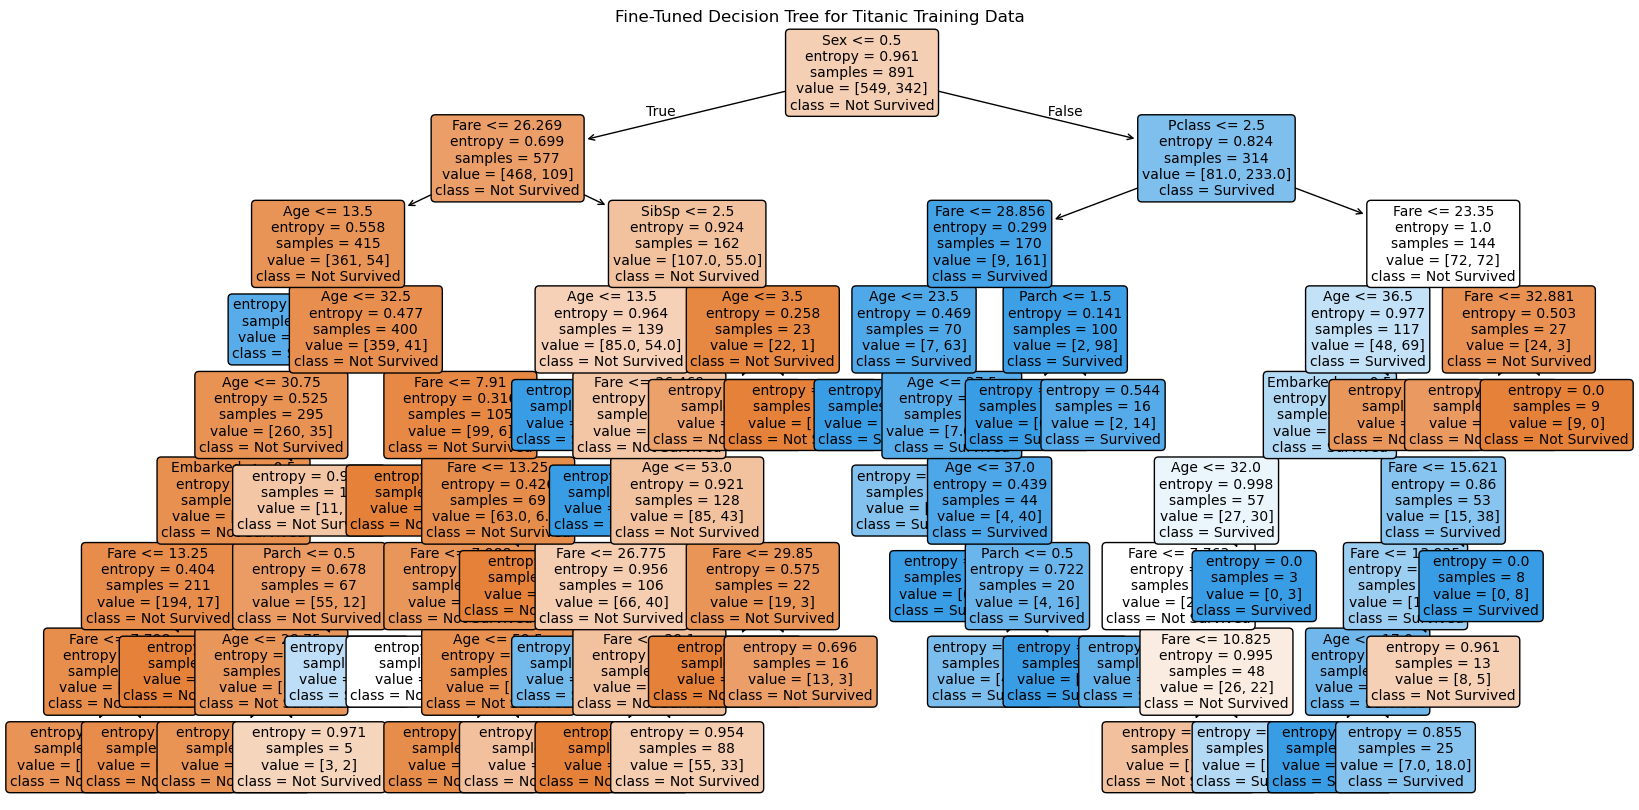

In [22]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Fine-Tuned Decision Tree for Titanic Training Data")
plt.show()

In [23]:
dt_scores = cross_val_score(best_dt, X, y, cv=5, scoring="accuracy")

print("Decision Tree 5-Fold CV Accuracies:", dt_scores)
print("Decision Tree Average CV Accuracy:", dt_scores.mean())

Decision Tree 5-Fold CV Accuracies: [0.80446927 0.80898876 0.84831461 0.83146067 0.86516854]
Decision Tree Average CV Accuracy: 0.8316803716025358


In [24]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X, y)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}

Best Random Forest CV Accuracy:
0.8316866486723997


In [25]:
best_rf = rf_grid.best_estimator_
best_rf.fit(X, y)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
rf_scores = cross_val_score(best_rf, X, y, cv=5, scoring="accuracy")

print("Random Forest 5-Fold CV Accuracies:", rf_scores)
print("Random Forest Average CV Accuracy:", rf_scores.mean())

Random Forest 5-Fold CV Accuracies: [0.79888268 0.82022472 0.88202247 0.80337079 0.85393258]
Random Forest Average CV Accuracy: 0.8316866486723997


In [27]:
print("Final Comparison")
print("-" * 40)
print("Decision Tree Average CV Accuracy :", dt_scores.mean())
print("Random Forest Average CV Accuracy:", rf_scores.mean())

if rf_scores.mean() > dt_scores.mean():
    print("\nRandom Forest performs better based on average 5-fold CV accuracy.")
elif dt_scores.mean() > rf_scores.mean():
    print("\nDecision Tree performs better based on average 5-fold CV accuracy.")
else:
    print("\nBoth models perform equally based on average 5-fold CV accuracy.")

Final Comparison
----------------------------------------
Decision Tree Average CV Accuracy : 0.8316803716025358
Random Forest Average CV Accuracy: 0.8316866486723997

Random Forest performs better based on average 5-fold CV accuracy.


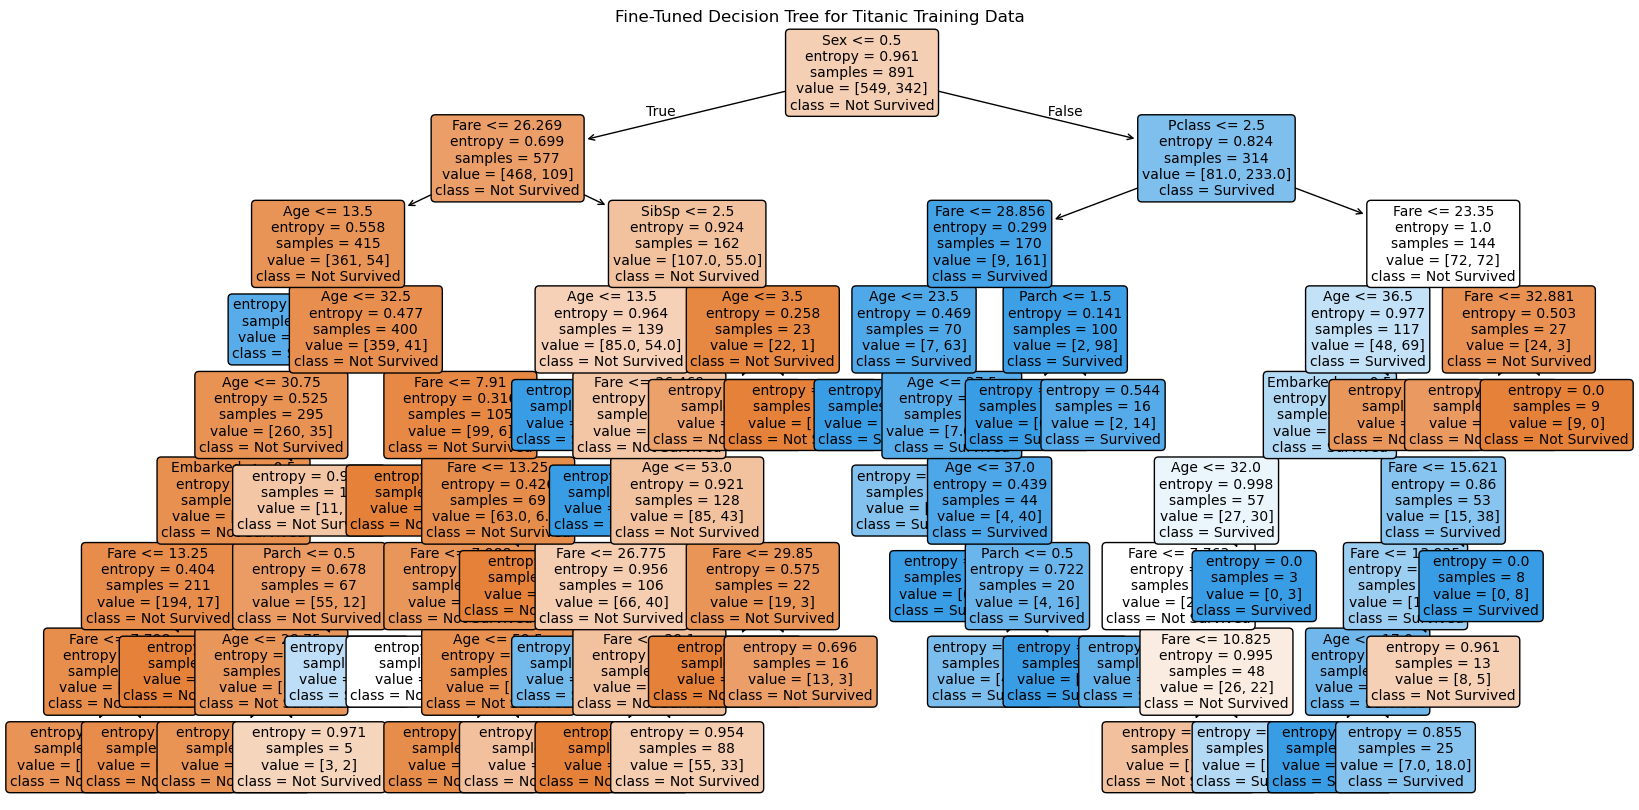

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Fine-Tuned Decision Tree for Titanic Training Data")
plt.savefig("decision_tree_plot.png", bbox_inches="tight")
plt.show()